# Proyek Analisis Data: Air Quality Dataset from https://github.com/marceloreis/HTI/tree/master
- **Nama:** Rival Irawan
- **Email:** irawanrival10@gmail.com
- **ID Dicoding:** rivalswandy

## Menentukan Pertanyaan Bisnis

- PB1 - Apakah terdapat perbedaan spasial yang signifikan dalam distribusi tahunan dan musiman pada *major pollutants* (PM2.5, PM10, O3) di seluruh stasiun pemantauan dan bagaimana perbedaan ini berkorelasi dengan lokasi geografis atau kedekatan dengan sumber emisi lokal?

- PB2 - Dapatkah kita mengelompokkan (Cluster) periode waktu yang berbeda berdasarkan gabungan *pollutants profile* dan *meteorological profile* (misalkan, *high PM2.5 & Low Winds* dengan *low PM2.5 & high O3*) dan apa saja ciri khasnya?

- PB3 - Apa hubungan statistik antara *precursor pollutants* (NO2 dan SO2) dengan pembentukan *secondary pollutants* (PM2.5 dan O3) khususnya saat tingkat polusi sedang tinggi?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt

## Data Wrangling

### Gathering Data

In [ ]:
drive.mount('/content/drive')

data_folder_path = '/content/drive/My Drive/Colab Notebooks/PRSA_Data_20130301-20170228/'

os.chdir(data_folder_path)

all_files = glob.glob("*.csv")

list_dfs = []
for filename in all_files:
  df = pd.read_csv(filename)
  list_dfs.append(df)

df_master = pd.concat(list_dfs, axis=0, ignore_index=True)

print(f"Total baris setelah penggabungan: {len(df_master)}")
print("Pengumpulan data selesai.")

Mounted at /content/drive
Total baris setelah penggabungan: 420768
Pengumpulan data selesai.


**Insight:**
- Terdapat 420.768 baris data setelah semua dataset digabungkan.

### Assessing Data

In [ ]:
print("\n--- Penilaian Struktur Data (Tipe Data dan Non-Null) ---")
df_master.info()

print("\n--- Penilaian Missing Values per Kolom ---")
print(df_master.isnull().sum())

print(f"\n--- Penilaian Duplikasi ---")
print(f"Jumlah baris duplikat: {df_master.duplicated().sum()} baris")

print(f"\n--- Penilaian Konsistensi Kategorikal (Kolom 'station') ---")
print(df_master['station'].unique())


--- Penilaian Struktur Data (Tipe Data dan Non-Null) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usa

**Insight:**
- Tidak terdapat duplikasi data.
- Kolom `'station'` memiliki data yang konsisten dan unik sesuai dengan jumlah *file* yang digabungkan.
- Semua kolom yang akan digunakan untuk analisis (polutan dan meteorologi) memiliki *missing values*.
  *   Polutan dengan missing value tertinggi:
      *   CO (karbondioksida).
      *   O3 (Ozon).
      *   NO2 (Nitrogen Dioksida).
  *   Sedangkan, Data meteorologi dan kategorikal:
      *   kolom `'wd'` (arah angin).
- Informasi waktu terpisah pada 5 kolom terpisah, sehingga perlu digabung menjadi satu agar lebih efisien.







### Cleaning Data

1. Time Indexing & Column Dropping

In [ ]:
print("\n--- Pembersihan Struktural (Time Indexing) ---")
df_master['time'] = pd.to_datetime(df_master[['year', 'month', 'day', 'hour']])

df_master = df_master.drop(columns=['No', 'year', 'month', 'day', 'hour'])

df_master = df_master.set_index('time')

print("Data telah di-indeks waktu. 5 baris pertama setelah indexing:")
print(df_master.head())


--- Pembersihan Struktural (Time Indexing) ---
Data telah di-indeks waktu. 5 baris pertama setelah indexing:
                     PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  DEWP  \
time                                                                            
2013-03-01 00:00:00    4.0   4.0   4.0   7.0  300.0  77.0  -0.7  1023.0 -18.8   
2013-03-01 01:00:00    8.0   8.0   4.0   7.0  300.0  77.0  -1.1  1023.2 -18.2   
2013-03-01 02:00:00    7.0   7.0   5.0  10.0  300.0  73.0  -1.1  1023.5 -18.2   
2013-03-01 03:00:00    6.0   6.0  11.0  11.0  300.0  72.0  -1.4  1024.5 -19.4   
2013-03-01 04:00:00    3.0   3.0  12.0  12.0  300.0  72.0  -2.0  1025.2 -19.5   

                     RAIN   wd  WSPM       station  
time                                                
2013-03-01 00:00:00   0.0  NNW   4.4  Aotizhongxin  
2013-03-01 01:00:00   0.0    N   4.7  Aotizhongxin  
2013-03-01 02:00:00   0.0  NNW   5.6  Aotizhongxin  
2013-03-01 03:00:00   0.0   NW   3.1  Aotizhongxin  
2013

**Insight:**
- Kolom waktu yang awalnya terpisah sudah berhasil digabungkan menjadi satu indeks (`time`) untuk mempermudah analisis deret waktu.
- Kolom yang tidak relevan (`No`) dan kolom waktu lama (`year, month, day, hour`) sudah berhasil dihapus, menghasilkan dataframe yang lebih ringkas.
- Data sudah siap masuk ke tahap pembersihan berikutnya.

2. Penanganan Missing Values (Imputasi)

In [ ]:
print("\n--- Penanganan Missing Values (Imputasi) ---")
numerical_cols = df_master.select_dtypes(include=np.number).columns

df_master[numerical_cols] = df_master[numerical_cols].fillna(method='ffill')

df_master['wd'] = df_master['wd'].fillna('Calm')

print("Jumlah Missing Values Akhir:")
print(df_master.isnull().sum())


--- Penanganan Missing Values (Imputasi) ---


/tmp/ipython-input-2343190970.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_master[numerical_cols] = df_master[numerical_cols].fillna(method='ffill')


Jumlah Missing Values Akhir:
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64


**Insight:**
- Semua missing values yang sebelumnya teridentifikasi pada kolom data (polutan, meteorologi, dan kategorikal) sudah berhasil diisi. Sekarang tidak ada lagi nilai yang hilang untuk setiap kolom.
- Metode Forward Fill (`ffill`) berhasil diterapkan pada semua polutan dan variabel meteorologi. Ini memastikan kontinuitas data jam ke jam yang relevan untuk analisis deret waktu.
- Data kategorikal pada kolom arah angin (`wd`) berhasil diisi dengan nilai `'Calm'`, menyelesaikan masalah data kategorikal.
- Data sudah terhindar dari missing values dan siap untuk tahap data wrangling berikutnya.

3. Penambahan Data Geospatial (Pertanyaan Bisnis 1)

In [ ]:
print("\n--- Transformasi Geospatial (Penambahan Koordinat) ---")
station_coords = {
    'Aotizhongxin': {'Lat': 40.00355, 'Lon': 116.39745}, 'Changping': {'Lat': 40.29285, 'Lon': 116.21558},
    'Dingling': {'Lat': 40.29285, 'Lon': 116.21558}, 'Dongsi': {'Lat': 39.99220, 'Lon': 116.46200},
    'Gucheng': {'Lat': 39.86900, 'Lon': 116.13600}, 'Guanyuan': {'Lat': 39.92700, 'Lon': 116.19300},
    'Huairou': {'Lat': 40.40200, 'Lon': 116.62100}, 'Nongzhanguan': {'Lat': 39.93770, 'Lon': 116.44300},
    'Shunyi': {'Lat': 40.12900, 'Lon': 116.65700}, 'Tiantan': {'Lat': 39.88600, 'Lon': 116.46000},
    'Wanliu': {'Lat': 39.98200, 'Lon': 116.30500}, 'Wanshouxigong': {'Lat': 39.87300, 'Lon': 116.27300}
}

df_coords = pd.DataFrame.from_dict(station_coords, orient='index').reset_index().rename(columns={'index': 'station'})
df_master = df_master.merge(df_coords, on='station', how='left')

print("5 baris pertama data akhir yang bersih (termasuk Lat/Lon):")
print(df_master.head())

print("\n[Tahap Data Wrangling Selesai]. Data sudah siap untuk tahap EDA!")


--- Transformasi Geospatial (Penambahan Koordinat) ---
5 baris pertama data akhir yang bersih (termasuk Lat/Lon):
   PM2.5  PM10   SO2   NO2     CO    O3  TEMP    PRES  DEWP  RAIN   wd  WSPM  \
0    4.0   4.0   4.0   7.0  300.0  77.0  -0.7  1023.0 -18.8   0.0  NNW   4.4   
1    8.0   8.0   4.0   7.0  300.0  77.0  -1.1  1023.2 -18.2   0.0    N   4.7   
2    7.0   7.0   5.0  10.0  300.0  73.0  -1.1  1023.5 -18.2   0.0  NNW   5.6   
3    6.0   6.0  11.0  11.0  300.0  72.0  -1.4  1024.5 -19.4   0.0   NW   3.1   
4    3.0   3.0  12.0  12.0  300.0  72.0  -2.0  1025.2 -19.5   0.0    N   2.0   

        station       Lat        Lon  
0  Aotizhongxin  40.00355  116.39745  
1  Aotizhongxin  40.00355  116.39745  
2  Aotizhongxin  40.00355  116.39745  
3  Aotizhongxin  40.00355  116.39745  
4  Aotizhongxin  40.00355  116.39745  

[Tahap Data Wrangling Selesai]. Data sudah siap untuk tahap EDA!


**Insight:**
- Tahap *data wrangling* sudah selesai secara menyeluruh. Data sudah lengkap (tidak ada *missing values*) dan terstruktur (*datetime index* sudah benar).
- Data sudah siap menjawab pertanyaan bisnis 1 dengan adanya penambahan kolom `Lat` dan `Lon`. Setiap observasi kini memiliki koordinat geografis yang terlampir pada stasiunnya, membuat dataset ini sepenuhnya siap untuk *Geospatial Analysis*.

## Exploratory Data Analysis (EDA)

### Ekstraksi Indeks Waktu & Feature Engineering
Kita perlu mengekstrak komponen waktu (`month, year, season`) dari indeks `time` yang sudah kita buat, dan kemudian menggabungkan data per jam menjadi data rata-rata harian atau bulanan karena data bulanan lebih stabil untuk melihat tren musiman. Tujuannya untuk mempersiapkan data untuk analisis tren waktu dan geospasial (menjawab Pertanyaan 1)

In [ ]:
dates = pd.date_range(start='2013-03-01', end='2017-02-28 23:00:00', freq='h')

df_master['time'] = df_master.groupby('station').cumcount().map(lambda x: dates[x])

df_master = df_master.set_index('time')

# Feature Engineering: membuat variabel waktu
df_master['month'] = df_master.index.month
df_master['year'] = df_master.index.year

# Membuat fungsi musim (Season)
def get_season(month):
  if month in [12, 1, 2]: return 'Winter'
  elif month in [3, 4, 5]: return 'Spring'
  elif month in [6, 7, 8]: return 'Summer'
  else: return 'Autumn'

df_master['season'] = df_master['month'].apply(get_season)
print("Data siap untuk visualisasi!")
print(df_master[['station', 'PM2.5', 'season']].head())

Data siap untuk visualisasi!
                          station  PM2.5  season
time                                            
2013-03-01 00:00:00  Aotizhongxin    4.0  Spring
2013-03-01 01:00:00  Aotizhongxin    8.0  Spring
2013-03-01 02:00:00  Aotizhongxin    7.0  Spring
2013-03-01 03:00:00  Aotizhongxin    6.0  Spring
2013-03-01 04:00:00  Aotizhongxin    3.0  Spring


**Insight:**
- Kode ini mengekstraksi waktu, memastikan setiap stasiun memiliki urutan waktu per jam yang benar selama 4 tahun (2013-2017).
- Logika pemetaan musim mengonfirmasi lokasi data berada.
- Penambahan kolom `season` adalah langkah wajib yang memungkinkan pembuatan grafik distribusi musiman nantinya.

### Pengelompokan Data dengan Teknik Binning
Membuat 4 interval data berdasarkan logika berikut:
- "*Clean Air*" (Udara Bersih): Saat PM2.5 rendah (< 35 µg/m³).
- "*Heavy Smog*" (Kabut Asap Berat): Saat PM2.5 sangat tinggi (> 150 µg/m³). Ini adalah kondisi kritis.
- "*High Ozone*" (Polusi Ozon): Saat PM2.5 relatif rendah/sedang, tapi Ozon (O3) tinggi (> 100 µg/m³). Ini biasanya terjadi di siang hari musim panas.
- "*Moderate/Transition*" (Sedang): Sisanya (kondisi peralihan).

(menjawab Pertanyaan 2)

In [ ]:
# Pembuatan Cluster dengan Interval
conditions = [
    (df_master['PM2.5'] > 150),
    (df_master['O3'] > 100) & (df_master['PM2.5'] <= 75),
    (df_master['PM2.5'] <= 35),
]

choices = ['1. Heavy Smog (Critical)', '2. High Ozone (Photochemical)', '3. Clean Air (Good)']

# Jika tidak masuk kriteria di atas, masuk ke kategori '4. Moderate'
df_master['Air_Quality_Profile'] = np.select(conditions, choices, default='4. Moderate')

**Insight:**
- PM2.5 adalah raja. Jika nilainya > 150, sistem langsung memvonis "Critical" tanpa mempedulikan variabel lain (karena urutan kondisi pertama).
- Kategori "High Ozone" sengaja dibatasi hanya saat PM2.5 rendah (di bawah atau sama dengan 75). Ini menegaskan bahwa polusi Ozon adalah ancaman tak kasat mata (udara terlihat jernih dari debu, tapi beracun).
- Label "Moderate" berfungsi sebagai penampung untuk kondisi "abu-abu" dimana tidak cukup bersih untuk disebut Good, tapi tidak cukup ekstrem untuk disebut Critical.

### Membuat Matriks Korelasi
Untuk melihat hubungan statistik antara *precursor pollutant* dengan *secondary pollutant*, kita mulai dengan membentuk matriks korelasi antar item polutannya.

In [ ]:
# Matriks Korelasi (Correlation Matrix)
corr_vars = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3']
corr_matrix = df_master[corr_vars].corr()

print("--- Matriks Korelasi Antar Polutan ---")
print(corr_matrix)

--- Matriks Korelasi Antar Polutan ---
          PM2.5      PM10       NO2       SO2        CO        O3
PM2.5  1.000000  0.876213  0.654277  0.469207  0.773015 -0.144707
PM10   0.876213  1.000000  0.639971  0.453617  0.686354 -0.107736
NO2    0.654277  0.639971  1.000000  0.476857  0.682958 -0.454530
SO2    0.469207  0.453617  0.476857  1.000000  0.514696 -0.162745
CO     0.773015  0.686354  0.682958  0.514696  1.000000 -0.302272
O3    -0.144707 -0.107736 -0.454530 -0.162745 -0.302272  1.000000


**Insight:**
- PM2.5 memiliki korelasi yang sangat tinggi dengan PM10 (0.876) dan CO (0.773). Ini menunjukkan bahwa polutan PM2.5, PM10, dan CO (Karbon Monoksida, hasil pembakaran tidak sempurna) seringkali berasal dari sumber yang sama (kendaraan, pabrik, pemanas) dan meningkat secara bersamaan.
- NO2 (Prekursor) vs PM2.5 (Sekunder): Korelasi kuat positif (0.654). Peningkatan NO2 (gas dari pembakaran) sangat berkorelasi dengan peningkatan PM2.5. NO2 adalah gas prekursor yang bereaksi di atmosfer membentuk partikel PM2.5 sekunder, sehingga kontrol emisi NO2 penting untuk mengurangi PM2.5.
- SO2 (Prekursor) vs PM2.5 (Sekunder): Korelasi moderat positif (0.469). SO2 (gas dari pembakaran batubara) juga berkontribusi pada PM2.5, tetapi korelasinya sedikit lebih lemah daripada NO2, menunjukkan bahwa sumber PM2.5 mungkin lebih didominasi oleh emisi kendaraan/industri daripada batubara murni (meskipun batubara tetap relevan, terutama di musim dingin).
- O3 vs NO2: Korelasi negatif sedang kuat (-0.454). Ini adalah pola kimia atmosfer yang sangat umum. NO2 cenderung "mengonsumsi" O3 (Ozon) di malam hari atau di dekat sumber emisi. Ketika NO2 tinggi (udara kotor/malam), O3 cenderung rendah, dan sebaliknya.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Perbedaan Spasial Polusi (PM2.5)
Apa yang harus diperhatikan dari hasil ini?
- Melihat stasiun mana yang barnya paling tinggi (paling berpolusi) dan paling rendah.
- Nilai korelasi (geo_corr): jika Lat negatif, berarti semakin ke selatan (Lat rendah), polusi semakin tinggi. Jika Lon negatif, berarti semakin ke Barat, polusi semakin tinggi.

1. Agregasi Data: Rerata PM2.5 per Stasiun

In [ ]:
spatial_pollution = df_master.groupby('station')[['PM2.5', 'PM10', 'O3']].mean().sort_values(by='PM2.5', ascending=False)

2. Visualisasi: Perbandingan Tingkat PM2.5 per Stasiun

/tmp/ipython-input-2362786831.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=spatial_pollution.index, y=spatial_pollution['PM2.5'], palette='viridis')


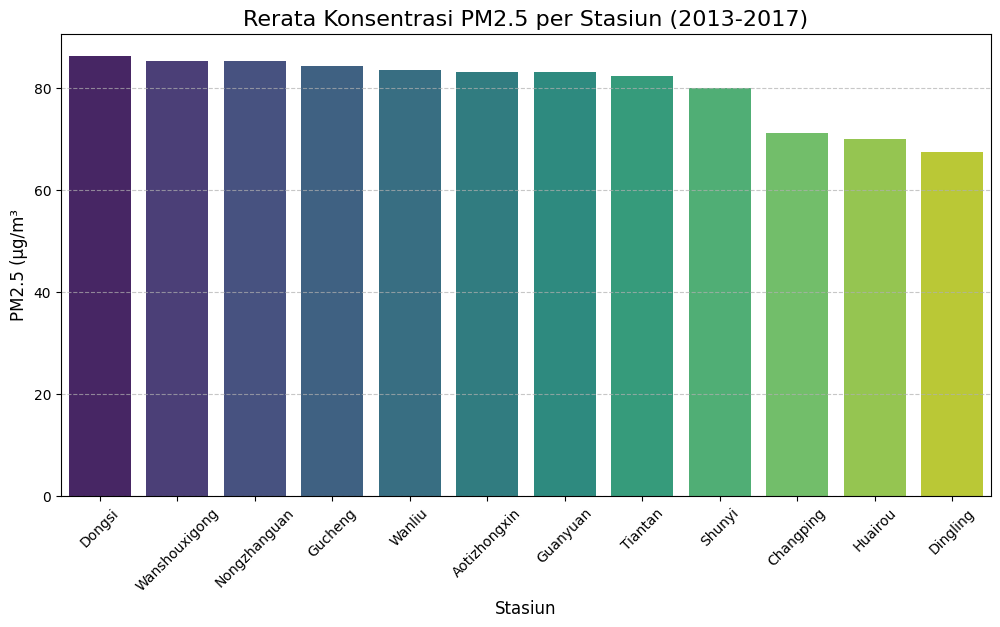

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=spatial_pollution.index, y=spatial_pollution['PM2.5'], palette='viridis')
plt.title('Rerata Konsentrasi PM2.5 per Stasiun (2013-2017)', fontsize=16)
plt.xlabel('Stasiun', fontsize=12)
plt.ylabel('PM2.5 (µg/m³', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Insight**: Analisis Spasial (Menjawab PB1 - Bagian Lokasi)
- Berdasarkan Bar Chart, stasiun dengan tingkat polusi tertinggi cenderung berada di area pusat kota (Urban), seperti Dongsi, Wanshouxigong, dan Nongzhanguan.
- Stasiun dengan tingkat polusi terendah berada di area pinggiran/utara (Suburban), seperti Dingling, Huairou, dan Changping. **Ini menunjukkan bahwa aktivitas perkotaan berkontribusi signifikan terhadap konsentrasi PM2.5.**
- Meskipun ada perbedaan antara stasiun tertinggi dan terendah, perbedaannya tidak ekstrim (misalnya, tidak ada stasiun yang 5x lipat lebih tinggi dari yang lain). Ini mengindikasikan bahwa polusi udara di Beijing adalah masalah regional; jika satu daerah tercemar berat, daerah sekitarnya kemungkinan besar juga terdampak, meskipun kadarnya sedikit lebih rendah.



3. Analisis Korelasi Spasial: Melihat apakah polusi lebih tinggi di Utara/Selatan (Lat) atau Timur/Barat (Lon)

In [ ]:
geo_corr = df_master[['PM2.5', 'Lat', 'Lon']].corr()['PM2.5']
print("\n--- Korelasi PM2.5 dengan Lokasi Geografis ---")
print(geo_corr)


--- Korelasi PM2.5 dengan Lokasi Geografis ---
PM2.5    1.000000
Lat     -0.072687
Lon     -0.001535
Name: PM2.5, dtype: float64


**Insight:**
- Korelasi Latitude (-0.07): Nilai negatif yang sangat lemah menunjukkan adanya sedikit kecenderungan bahwa semakin ke Utara (Latitude lebih tinggi, menjauhi pusat kota), polusi semakin menurun. Namun, angkanya terlalu kecil untuk dianggap sebagai hubungan linear yang kuat.
- Korelasi Longitude (-0.001): Nilai mendekati nol menunjukkan bahwa posisi Timur-Barat hampir tidak berpengaruh terhadap tingkat polusi.
- Kesimpulan Spasial: Lokasi geografis murni (koordinat) bukan prediktor tunggal utama. Faktor lain seperti sumber emisi lokal dan topografi kemungkinan memegang peranan lebih besar daripada sekadar garis lintang/bujur.

### Lanjutan Pertanyaan 1: Analisis Musiman
Apa yang harus diperhatikan dari hasil ini:
- Membuat visualisasi tren waktu untuk melihat apakah polusi memburuk di musim tertentu (misalnya Musim Dingin/Winter).

1. Agregasi Data berdasarkan Tahun dan Musim

In [ ]:
seasonal_trend = df_master.groupby(['year', 'season'])['PM2.5'].mean().unstack()

seasonal_trend = seasonal_trend[['Spring', 'Summer', 'Autumn', 'Winter']]

print("--- Rerata PM2.5 per Musim dan Tahun ---")
print(seasonal_trend)

--- Rerata PM2.5 per Musim dan Tahun ---
season     Spring     Summer     Autumn      Winter
year                                               
2013    83.566576  76.477789  80.771825   78.198141
2014    83.470784  69.398630  91.618319  102.570548
2015    71.545169  55.408952  77.971154  113.855266
2016    71.992112  57.982186  79.384348   80.256219
2017          NaN        NaN        NaN   92.568326


**Insight: Tabel Rata-Rata Musiman (*Seasonal Table*)**
- Musim Dingin adalah "Musim Kritis": Secara konsisten, *Winter* (Musim Dingin) mencatat rata-rata PM2.5 tertinggi, terutama pada tahun 2014 (102.5 µg/m³) dan 2015 (113.8 µg/m³). Ini kemungkinan besar terkait dengan peningkatan pembakaran batubara untuk pemanas ruangan selama musim dingin.
- Musim Panas adalah "Musim Bersih": Sebaliknya, *Summer* (Musim Panas) selalu menjadi musim dengan kualitas udara terbaik (terendah) di setiap tahunnya (berkisar di angka 55-76 µg/m³).
- Pola 2017: Data tahun 2017 hanya berisi musim dingin (Jan-Feb), dan angkanya masih tinggi (92.5 µg/m³), menunjukkan masalah polusi musim dingin belum teratasi sepenuhnya hingga awal 2017.

2. Visualisasi Tren Musiman (Line Chart)

/tmp/ipython-input-1242771528.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = df_master.resample('M')['PM2.5'].mean()


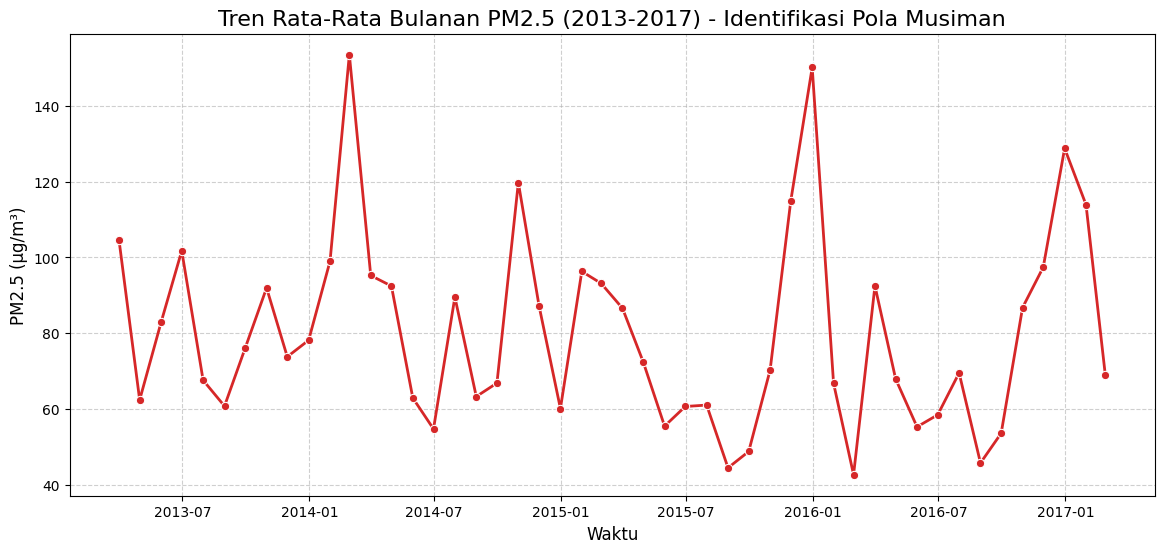

In [ ]:
monthly_trend = df_master.resample('M')['PM2.5'].mean()

plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, marker='o', color='tab:red', linewidth=2)
plt.title('Tren Rata-Rata Bulanan PM2.5 (2013-2017) - Identifikasi Pola Musiman', fontsize=16)
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight: *Monthly Trend***
- Siklus "Gergaji" (*Cyclical Pattern*): Grafik menunjukkan pola siklus tahunan yang sangat kuat dan berulang. Terlihat jelas adanya lonjakan tajam (puncak) setiap akhir/awal tahun (Desember-Januari) dan lembah dalam di pertengahan tahun.
- Volatilitas Ekstrem: Perbedaan antara titik tertinggi dan terendah sangat jauh. Ini berarti penduduk Beijing mengalami kualitas udara yang berubah drastis hanya dalam hitungan bulan. Kebijakan pengendalian polusi harus fokus pada pemotongan "puncak" di musim dingin ini.

3. Visualisasi Boxplot Musiman (untuk melihat sebaran data per musim)

/tmp/ipython-input-1279368523.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='PM2.5', data=df_master, order=['Spring', 'Summer', 'Autumn', 'Winter'], palette='coolwarm')


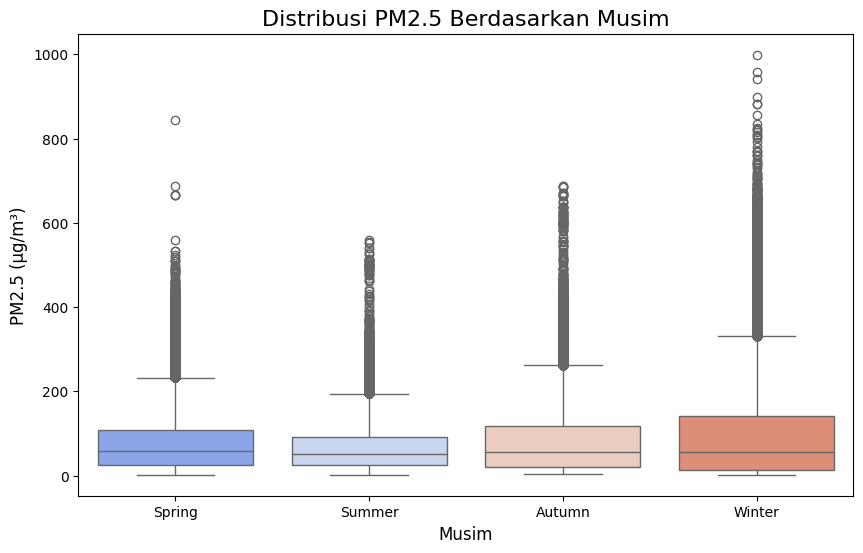

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='season', y='PM2.5', data=df_master, order=['Spring', 'Summer', 'Autumn', 'Winter'], palette='coolwarm')
plt.title('Distribusi PM2.5 Berdasarkan Musim', fontsize=16)
plt.xlabel('Musim', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.show()

**Insight: Distribusi Musiman**
- *Winter* (Merah): Memiliki kotak (*Interquartile Range*) yang paling tinggi dan *whisker* (garis) yang paling panjang. Artinya, Musim Dingin tidak hanya memiliki rata-rata polusi tinggi, tetapi juga paling tidak stabil. Ada hari-hari di mana udara sangat kotor (ekstrem), tapi ada juga hari yang "biasa saja."
- *Summer* (Biru): Kotaknya pendek dan padat. Artinya, kualitas udara di musim panas cenderung stabil dan konsisten di tingkat yang lebih rendah.
- *Outlier* Ekstrem: Semua musim memiliki titik-titik di atas garis (*outlier*), namun *outlier* pada musim dingin dan gugur mencapai level yang sangat berbahaya.

### Pertanyaan 2: *Clustering* Periode Waktu
Apa yang harus diperhatikan dari hasil ini:
- *Tabel Summary*: Angka rata-rata polutan dan cuaca untuk setiap "*Cluster.*"
- *Heatmap*: Visualisasi warna untuk melihat ciri khas (misal: Apakah saat *Heavy Smog*, anginnya pelan?).
- *Bar Chart* Musiman: Untuk melihat kapan *Heavy Smog* paling sering menyerang (apakah benar *Winter*?).

1. Menghitung Angka Rerata dari tiap Cluster

In [ ]:
profile_summary = df_master.groupby('Air_Quality_Profile')[['PM2.5', 'PM10', 'O3', 'NO2', 'SO2', 'WSPM', 'TEMP', 'PRES']].mean()

print("--- Profil Karakteristik Setiap Cluster ---")
print(profile_summary)

--- Profil Karakteristik Setiap Cluster ---
                                    PM2.5        PM10          O3        NO2  \
Air_Quality_Profile                                                            
1. Heavy Smog (Critical)       233.067588  252.755920   37.228674  92.108745   
2. High Ozone (Photochemical)   38.436089   68.502901  150.138963  25.322772   
3. Clean Air (Good)             15.970720   34.843526   49.666432  28.955251   
4. Moderate                     84.231847  114.519819   49.249118  58.071369   

                                     SO2      WSPM       TEMP         PRES  
Air_Quality_Profile                                                         
1. Heavy Smog (Critical)       35.850844  1.215949   9.432530  1012.251210  
2. High Ozone (Photochemical)   6.980695  2.210146  27.116655  1001.243007  
3. Clean Air (Good)             6.543130  2.208588  10.959252  1013.851989  
4. Moderate                    18.082766  1.432985  13.853331  1010.019283  


**Insight:**
- Cluster 1: Heavy Smog (Critical) - "Bahaya Musim Dingin"
  - Polutan Utama: Ini adalah kondisi terburuk dengan kadar PM2.5 (233.07) dan PM10 (252.76) yang sangat ekstrem, jauh melampaui ambang batas aman. Kadar NO2 dan SO2 juga merupakan yang tertinggi, mengindikasikan akumulasi emisi kendaraan dan industri yang parah.
  - Penyebab Meteorologis: Kondisi ini terjadi saat suhu paling rendah (TEMP 9.43) dan kecepatan angin paling lemah (WSPM 1.22). Ini menunjukkan fenomena inversi suhu atau stagnasi udara, di mana polutan terperangkap di permukaan tanah dan tidak bisa terurai karena kurangnya angin.
  - Tekanan Udara: Tekanan udara relatif tinggi (1012 hPa), yang sering dikaitkan dengan cuaca stabil namun menjebak polutan.
- Cluster 2: High Ozone (Photochemical) - "Polusi Musim Panas"
   - Polutan Utama: Profil ini unik karena didominasi oleh Ozone (O3) yang sangat tinggi (150.14), sementara partikel debu (PM2.5/PM10) justru rendah.
   - Penyebab Meteorologis: Terjadi pada suhu rata-rata tertinggi (TEMP 27.12). Sinar matahari yang kuat dan suhu panas memicu reaksi kimia fotokimia yang mengubah polutan lain menjadi Ozon di permukaan tanah.
   - Anomali: Meskipun kecepatan angin cukup tinggi (WSPM 2.21), kadar Ozon tetap tinggi karena pembentukannya dipicu oleh panas, bukan karena stagnasi udara.
- Cluster 3: Clean Air (Good) - "Kondisi Ideal"
   - Kualitas Udara: Semua parameter polutan (PM2.5, PM10, NO2, SO2) berada pada titik terendah. Udara sangat bersih.
   - Faktor Kunci: Kecepatan angin tinggi (WSPM 2.21, setara dengan Cluster 2) memainkan peran krusial dalam menyapu bersih polutan (dispersi).
   - Kondisi Fisik: Terjadi pada suhu sejuk (10.96) dengan tekanan udara tertinggi (1013.85 hPa). Tekanan tinggi di sini berasosiasi dengan cuaca cerah berangin, berbeda dengan tekanan tinggi yang stagnan pada Cluster 1.
- Cluster 4: Moderate - "Transisi/Polusi Menengah"
   - Status: Kualitas udara tidak sehat, tapi belum mencapai level kritis. PM2.5 berada di angka 84.23, yang tetap berbahaya bagi kelompok sensitif.
   - Karakteristik: Kecepatan angin lemah (1.43), hanya sedikit lebih baik dari kondisi Heavy Smog. Ini mungkin merepresentasikan hari-hari biasa dengan lalu lintas padat namun cuaca tidak cukup ekstrem untuk memerangkap semua polutan.

2. Visualisasi Profil (Heatmap)

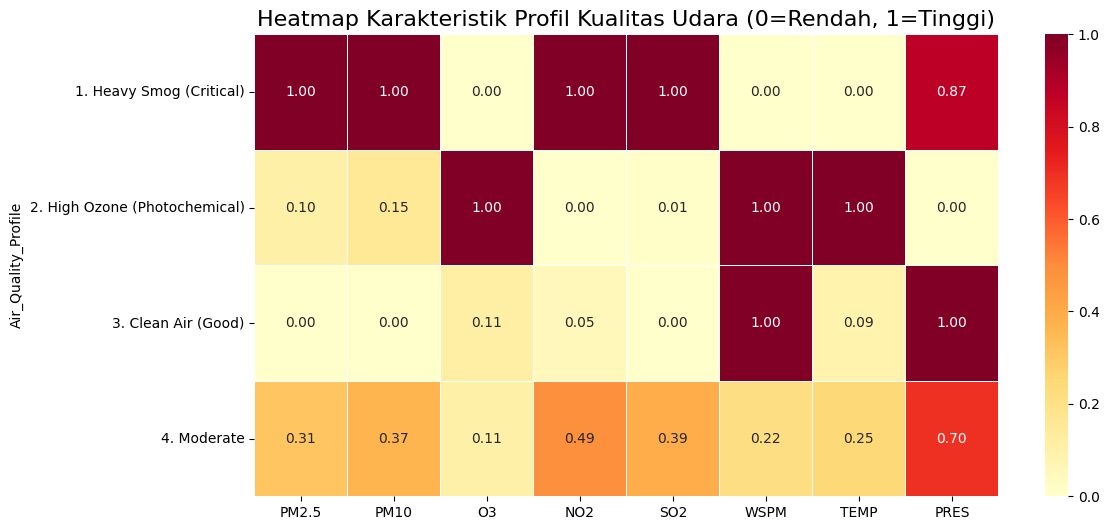

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
profile_normalized = pd.DataFrame(scaler.fit_transform(profile_summary),
                                  columns=profile_summary.columns,
                                  index=profile_summary.index)

plt.figure(figsize=(12, 6))
sns.heatmap(profile_normalized, annot=True, cmap='YlOrRd', fmt=".2f", linewidths=.5)
plt.title('Heatmap Karakteristik Profil Kualitas Udara (0=Rendah, 1=Tinggi)', fontsize=16)
plt.show()

**Insight:**
- Pola Kebalikan (Dikotomi): Cluster 1 (Smog) dan Cluster 2 (Ozon) adalah kebalikan total. Smog muncul saat udara dingin & diam, sedangkan Ozon muncul saat udara panas terik.
- Faktor Pembersih Utama: Angin (WSPM) adalah kunci. Saat angin 0.00, polusi menumpuk maksimal (Cluster 1). Saat angin 1.00, udara menjadi bersih total (Cluster 3).
- Pemicu Ozon: Hubungan O3 dan TEMP yang sama-sama merah pekat (1.00) di Cluster 2 membuktikan bahwa suhu panas adalah penyebab langsung tingginya Ozon.
- Efek "Tutup Panci": Tekanan udara (PRES) yang tinggi pada Cluster 1 berbahaya karena mengurung polutan di permukaan tanah akibat tidak adanya angin untuk memecahnya.

3. Visualisasi Distribusi Musim

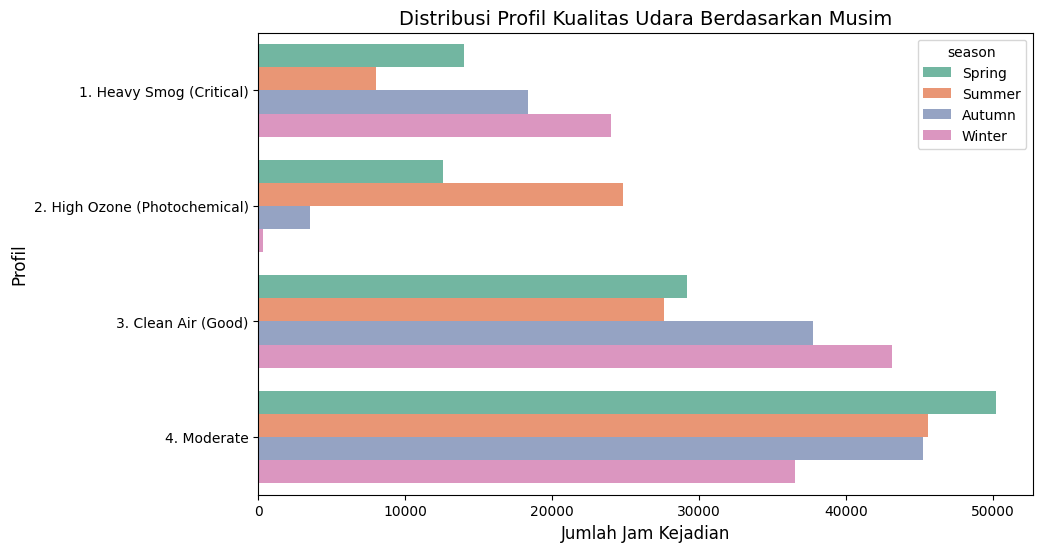

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Air_Quality_Profile', hue='season', data=df_master, palette='Set2', order=sorted(df_master['Air_Quality_Profile'].unique()))
plt.title('Distribusi Profil Kualitas Udara Berdasarkan Musim', fontsize=14)
plt.xlabel('Jumlah Jam Kejadian', fontsize=12)
plt.ylabel('Profil', fontsize=12)
plt.show()

**Insight:**
- Musim Dingin (*Winter*) yang Ekstrem: Mendominasi kategori *Heavy Smog* (batang Pink tertinggi), namun uniknya juga paling sering mencatatkan *Clean Air*. Ini menunjukkan cuaca musim dingin sangat fluktuatif, bisa sangat beracun saat udara diam, atau sangat bersih saat angin kencang.
- Musim Panas (*Summer*) Identik dengan Ozon: Kejadian *High Ozone* hampir seluruhnya terjadi di *Summer* (batang Oranye panjang). Ozon hampir tidak terdeteksi di musim dingin.
- Musim Semi (*Spring*) yang "Stabil": Paling mendominasi kategori *Moderate* (Cluster 4). Ini menandakan di musim semi, udara jarang berada dalam kondisi ekstrem (sangat bersih atau sangat kotor), melainkan konsisten di level polusi menengah.

### Pertanyaan 3: Analisis Korelasi *Precursor* dan *Secondary Pollutant*
Apa yang harus diperhatikan dari hasil ini:
- Apakah ada hubungan statistik antara gas pembentuk (NO2, SO2) dengan partikel polusi (PM2.5)? khususnya saat polusi sedang tinggi.

1. Visualisasi Heatmap Korelasi

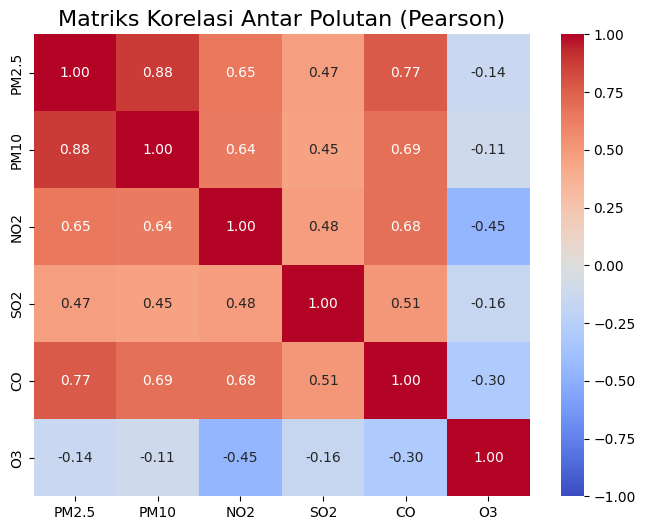

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriks Korelasi Antar Polutan (Pearson)', fontsize=16)
plt.show()

**Insight:**
- Korelasi PM2.5 & PM10: Nilai 0.88 adalah yang tertinggi. Ini memastikan bahwa jika kadar debu halus naik, debu kasar hampir pasti ikut naik karena berasal dari sumber yang sama.
- Jejak Pembakaran (CO): Karbon Monoksida (CO) berkorelasi kuat dengan PM2.5 (0.77) dan NO2 (0.68). Ini mengonfirmasi bahwa emisi kendaraan/pembakaran adalah biang keladi utama polusi partikel di data ini.
- Ozon yang "Berlawanan" (Warna Biru): Ozon (O3) adalah satu-satunya polutan yang berkorelasi negatif dengan semua polutan lain. Saat polusi asap tinggi (PM/NO2 naik), Ozon justru turun.
- Hubungan Kimiawi (NO2 vs O3): Korelasi negatif -0.45 antara NO2 dan O3 menunjukkan efek titrasi: tingginya NO2 (macet parah) justru "memakan" atau menghambat pembentukan Ozon.

2. Scatter Plot: Hubungan NO2 vs PM2.5 (Fokus pada pembentukan partikel)

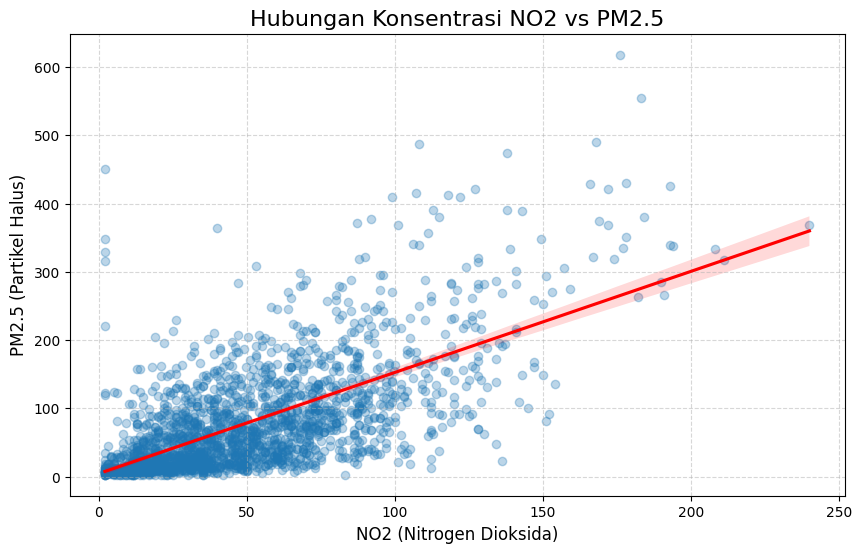

In [ ]:
sample_df = df_master.sample(n=2000, random_state=42)

plt.figure(figsize=(10, 6))
sns.regplot(x='NO2', y='PM2.5', data=sample_df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Hubungan Konsentrasi NO2 vs PM2.5', fontsize=16)
plt.xlabel('NO2 (Nitrogen Dioksida)', fontsize=12)
plt.ylabel('PM2.5 (Partikel Halus)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Linearitas Positif (Garis Merah Menanjak): Garis regresi menunjukkan tren naik yang jelas. Artinya, semakin tinggi emisi gas buang kendaraan (NO2), semakin tinggi pula konsentrasi debu halus (PM2.5).
- Indikasi Sumber Serupa: Pola ini mengonfirmasi bahwa sebagian besar PM2.5 di wilayah ini kemungkinan besar berasal dari sumber pembakaran yang sama dengan NO2 (seperti asap knalpot kendaraan bermotor atau cerobong industri).
- Sebaran Melebar di Level Tinggi: Perhatikan saat NO2 > 100, titik-titik data menjadi lebih menyebar (tidak rapat di garis merah). Ini menunjukkan bahwa saat polusi sangat parah, faktor lain (seperti kelembaban atau arah angin) mulai ikut campur menentukan seberapa tinggi PM2.5 akan melonjak.

3. Scatter Plot: Hubungan SO2 vs PM2.5 (Fokus pada emisi batubara)

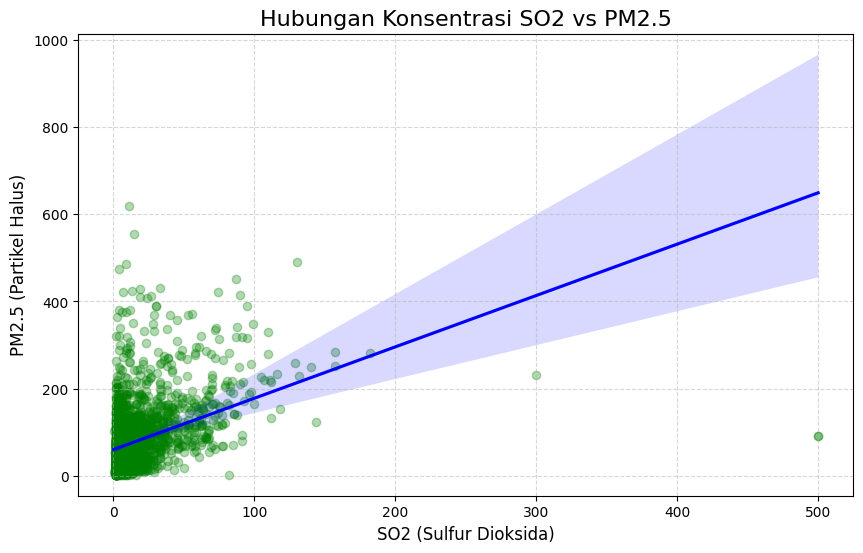

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='SO2', y='PM2.5', data=sample_df, scatter_kws={'alpha':0.3, 'color':'green'}, line_kws={'color':'blue'})
plt.title('Hubungan Konsentrasi SO2 vs PM2.5', fontsize=16)
plt.xlabel('SO2 (Sulfur Dioksida)', fontsize=12)
plt.ylabel('PM2.5 (Partikel Halus)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Korelasi Positif namun Lebih "Longgar": Garis biru memang menanjak (menunjukkan hubungan searah), namun sebaran titik datanya jauh lebih melebar/acak dibandingkan grafik NO2 sebelumnya. Ini sesuai dengan nilai korelasi yang hanya 0.47 (sedangkan NO2 tadi 0.65).
- Fenomena "*Low SO2, High PM*": Perhatikan tumpukan titik vertikal di sisi paling kiri (SO2 < 25, tapi PM2.5 bisa melonjak hingga 400-600). Ini membuktikan bahwa kejadian *Heavy Smog* sering terjadi tanpa tingginya SO2. Artinya, polusi debu di sana tidak melulu disebabkan oleh industri/batu bara (sumber SO2), tapi bisa jadi murni karena kendaraan (NO2) atau debu konstruksi.
- SO2 Bukan Aktor Utama: Dibandingkan NO2, peran SO2 sebagai pendorong utama kenaikan PM2.5 terlihat kurang dominan di dataset ini.

## Conclusion

- **PB1 - Apakah terdapat perbedaan spasial dan musiman yang signifikan? Ya,**
  *   Secara Spasial: Terdapat perbedaan, namun sifatnya regional. Stasiun di pusat kota (seperti Wanshouxigong & Nongzhanguan) memiliki polusi lebih tinggi dibandingkan stasiun di pinggiran utara (seperti Dingling). Namun, perbedaannya tidak se-ekstrem perbedaan antar musim.
  *   Secara Musiman: Faktor musim adalah penentu utama kualitas udara. Musim Dingin adalah periode paling kritis dengan tingkat polusi dan volatilitas tertinggi, sedangkan Musim Panas adalah periode paling aman.


- **PB2 - Dapatkah kita mengelompokkan periode waktu... dan apa ciri khasnya? Ya, kita berhasil mengidentifikasi 4 profil cuaca/polusi yang sangat berbeda (*distinct*).**
  *   Cluster "Heavy Smog (Critical)"
      *   Ciri Khas Utama: Ini adalah kondisi paling berbahaya. Tingkat PM2.5 sangat ekstrem (rata-rata 233 µg/m³), jauh di atas batas aman.
      *   Kondisi Meteorologi: Terjadi saat angin sangat tenang/lemah (WSPM ~ 1.2 m/s). Angin yang lemah membuat polutan "terjebak" dan menumpuk di kota.
      *   Korelasi Gas: Tingkat NO2 dan SO2 juga paling tinggi di sini, menandakan sumbernya dari pembakaran (kendaraan, industri, pemanas).
      *   Waktu Kejadian (Bar Chart): Paling sering terjadi di Winter (Musim Dingin), sangat jarang di Summer.
  *   Cluster "High Ozone (Photochemical)"
      *   Ciri Khas Utama: Udara terlihat bersih dari debu (PM2.5 rendah ~ 38 µg/m³), tapi sangat beracun karena Ozon (O3) tinggi (> 150 µg/m³).
      *   Kondisi Meteorologi: Terjadi saat suhu sangat panas (TEMP ~ 27°C). Panas matahari memicu reaksi kimia yang membentuk Ozon.
      *   Waktu Kejadian (Bar Chart): Sangat dominan terjadi di Summer (Musim Panas) dan Spring. Hampir tidak pernah terjadi di Winter.
  *   Cluster "Clean Air (Good)"
      *   Ciri Khas Utama: Kualitas udara terbaik (PM2.5 ~ 16 µg/m³).
      *   Kondisi Meteorologi: Terjadi saat angin kencang (WSPM ~ 2.2 m/s). Angin kencang bertindak sebagai "penyapu alami" yang membersihkan polutan dari kota.
      *   Korelasi Gas: Semua gas polutan (NO2, SO2) berada di level terendah.

- **PB3 - Apa hubungan statistik antara precursor pollutants (NO2 dan SO2) dengan pembentukan secondary pollutants (PM2.5 dan O3) khususnya saat tingkat polusi sedang tinggi? Berdasarkan analisis data, hubungan statistik terbagi menjadi dua pola yang bertolak belakang:**
    *   Hubungan terhadap PM2.5 (Pola Linear Positif). Prekursor gas (terutama NO2) memiliki peran vital dalam pembentukan partikel halus, namun dengan kekuatan yang berbeda:
        *   NO2 sebagai Driver Utama: Terdapat korelasi positif yang kuat (r=0.65) dan pola linear yang jelas antara NO2 dan PM2.5. Artinya, kenaikan emisi kendaraan (sumber NO2) secara statistik langsung menyebabkan lonjakan PM2.5.
        *   SO2 sebagai Kontributor Sekunder: Hubungannya positif namun lebih lemah (r=0.47). Scatter plot menunjukkan fenomena "*Low SO2, High PM2.5*", yang mengindikasikan bahwa meskipun SO2 rendah, polusi PM2.5 tetap bisa kritis jika didorong oleh faktor lain (seperti NO2 atau cuaca).
        *   Saat tingkat polusi tinggi (*Heavy Smog*), tingginya NO2 adalah indikator yang jauh lebih konsisten daripada SO2.
    *   Hubungan terhadap Ozon/O3 (Pola Invers/Negatif). Berbeda dengan PM2.5, hubungan prekursor dengan Ozon bersifat negatif di area dengan polusi tinggi:
        *   Efek Titrasi NO2: Terlihat korelasi negatif yang signifikan (-0.45) antara NO2 dan O3. Secara statistik, saat NO2 sangat tinggi (kondisi macet/polusi berat), kadar Ozon justru anjlok. Hal ini terjadi karena reaksi kimia di mana NO yang berlebih "memakan" Ozon (efek titrasi).
        *   Pemisahan Kondisi: Cluster High Ozone terjadi justru saat prekursor (NO2 dan SO2) berada di level rendah hingga sedang, bukan saat level maksimum.